# OLD CODE

_____________


In [5]:
import torch
torch.cuda.empty_cache()


Synthetic data created
EDA for data_old
Found classes : ['cat', 'dog']
 - Class 'cat' : 5 images
 - Class 'dog' : 5 images

Sample imaeg from data_old\cat\cat_0.png 
Format : PNG
Size : (32, 32)
Mode : RGB

--- DataLoader Test ---
Batch of images shape: torch.Size([4, 3, 32, 32])
Batch of labels shape: torch.Size([4])
Labels in batch: tensor([1, 1, 1, 0])
Image Distribution
       class  count
3   mountain   2512
2    glacier   2404
5     street   2382
4        sea   2274
1     forest   2271
0  buildings   2191


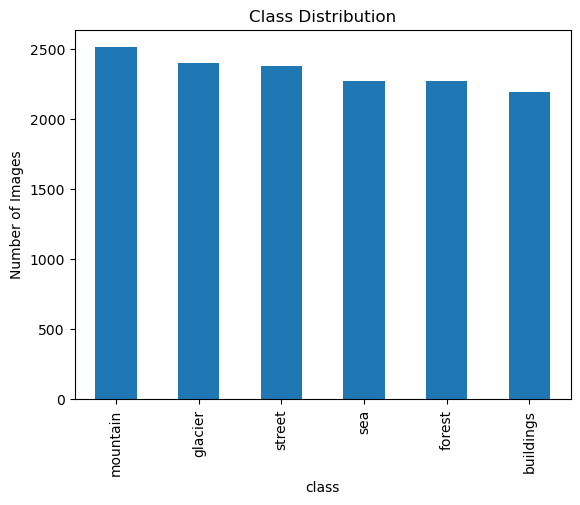

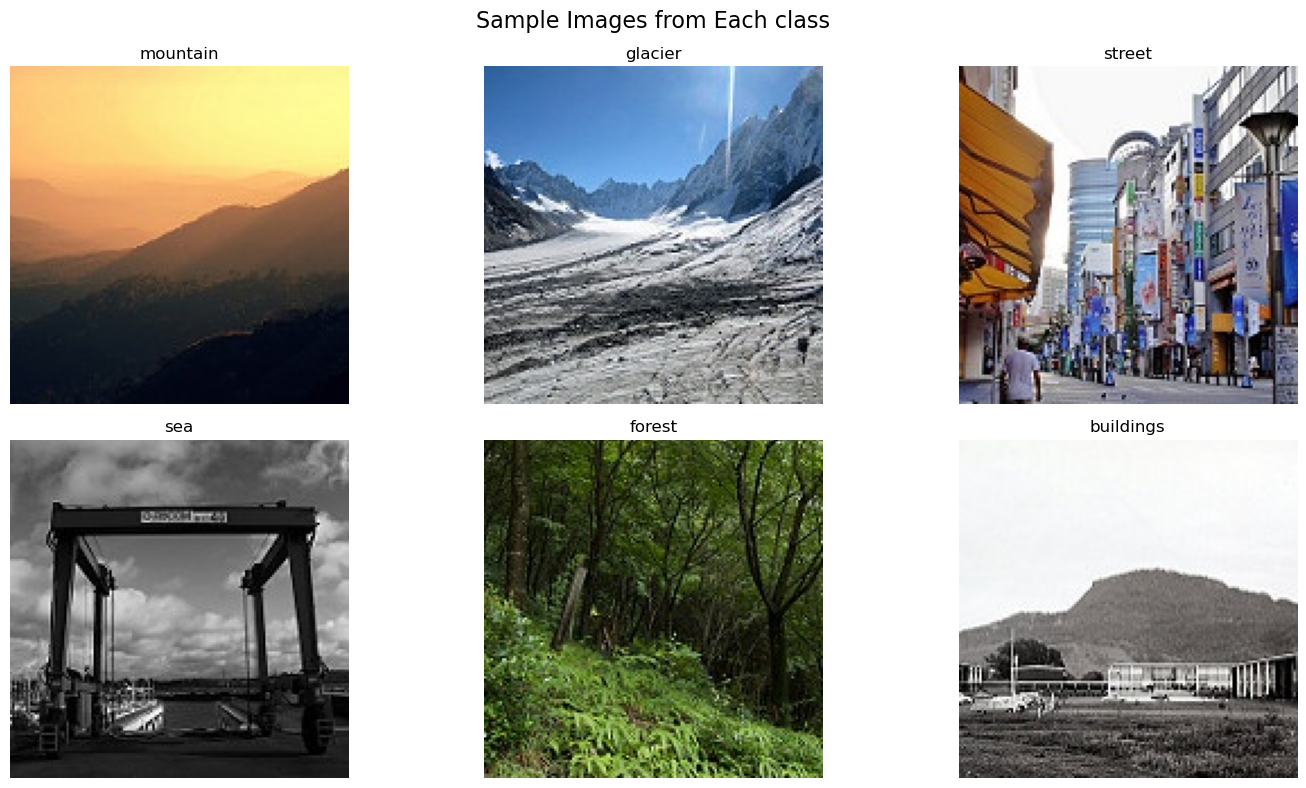

Loaded 14034 images for this crucible
Benchmarking with num_worker = 0
Loaded batch 50/220
Loaded batch 100/220
Loaded batch 150/220
Loaded batch 200/220
Time taken for the slow loader is  : 23.349380493164062
Benchmarking with num_workers = 8
  Loaded batch 50/220
  Loaded batch 100/220
  Loaded batch 150/220
  Loaded batch 200/220
Time taken with 8 workers: 50.25 seconds

Speed-up: 0.46x


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import transforms
from old_custom import CustomImageDataset

data_dir = "./data/seg_train/seg_train"

image_counts = []
for class_name in os.listdir(data_dir):
    class_dir = os.path.join(data_dir, class_name)

    if os.path.isdir(class_dir):
        count = len(os.listdir(class_dir))
        image_counts.append({'class' : class_name,
                             'count' : count})
        

# Display as a pretty data frame
df_counts = pd.DataFrame(image_counts).sort_values('count', ascending=False)
print("Image Distribution")
print(df_counts)

# Check for class imbalance
df_counts.plot(kind = 'bar',
               x = 'class',
               y='count',
               title='Class Distribution',
               legend=False)

plt.ylabel('Number of Images')
plt.show()


fig, axes = plt.subplots(2,3,
                         figsize=(15, 8))
fig.suptitle('Sample Images from Each class', fontsize =16)

axes = axes.flatten()

for i, class_name in enumerate(df_counts['class']):
    class_dir = os.path.join(data_dir, class_name)
    img_path = os.path.join(class_dir, os.listdir(class_dir)[0])
    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()




import time

# Adapt the class for the new data path

crucible_transform = transforms.Compose([
    transforms.Resize((150, 150)), # The images are 150x150
    transforms.ToTensor()
])

dataset = CustomImageDataset(root_dir=data_dir, transform=crucible_transform)

print(f"Loaded {len(dataset)} images for this crucible")

# Benchmark 1 : Single-Process data loading
print(f"Benchmarking with num_worker = 0")
# This is deafult. The main Python process loads all the data.
slow_loader = DataLoader(dataset=dataset, batch_size=64,
                         shuffle=True,
                         num_workers=0)

start_time = time.time()

for i, (images, labels) in enumerate(slow_loader):
    # This is only simulating a training loop by iterating
    if (i+1) % 50 == 0:
        print(f"Loaded batch {i + 1}/{len(slow_loader)}")
end_time = time.time()

slow_time = end_time - start_time
print(f"Time taken for the slow loader is  : {slow_time}")

# Benchmark 2 : Multi process data loading
num_cpu = os.cpu_count()
print(f"Benchmarking with num_workers = {num_cpu}")
# Spawns multiple processes to load data in paralletl, so the GPU wait

fast_loader = DataLoader(dataset=dataset, batch_size=64, shuffle=True,
                         num_workers=num_cpu)

start_time = time.time()
for i, (images, labels) in enumerate(fast_loader):
    if (i+1) % 50 == 0:
      print(f"  Loaded batch {i+1}/{len(fast_loader)}")
end_time = time.time()
fast_time = end_time - start_time

print(f"Time taken with {num_cpu} workers: {fast_time:.2f} seconds")
print(f"\nSpeed-up: {slow_time / fast_time:.2f}x")

_______

# Beginner
> What happens to the benchmark time if you set `batch_size` to 256? Does it become faster or slower per epoch? Why?
### Runnable code snippet is below: 
> The Answer is that loading becomes slower as it has to load 256 data-points into the memory

In [2]:
import time

# Adapt the class for the new data path

crucible_transform = transforms.Compose([
    transforms.Resize((150, 150)), # The images are 150x150
    transforms.ToTensor()
])

dataset = CustomImageDataset(root_dir=data_dir, transform=crucible_transform)

print(f"Loaded {len(dataset)} images for this crucible")

# Benchmark 1 : Single-Process data loading
print(f"Benchmarking with num_worker = 0")
# This is deafult. The main Python process loads all the data.
slow_loader = DataLoader(dataset=dataset, batch_size=256,
                         shuffle=True,
                         num_workers=0)

start_time = time.time()

for i, (images, labels) in enumerate(slow_loader):
    # This is only simulating a training loop by iterating
    if (i+1) % 50 == 0:
        print(f"Loaded batch {i + 1}/{len(slow_loader)}")
end_time = time.time()

slow_time = end_time - start_time
print(f"Time taken for the slow loader is  : {slow_time}")

# Benchmark 2 : Multi process data loading
num_cpu = os.cpu_count()
print(f"Benchmarking with num_workers = {num_cpu}")
# Spawns multiple processes to load data in paralletl, so the GPU wait

fast_loader = DataLoader(dataset=dataset, batch_size=256, shuffle=True,
                         num_workers=num_cpu)

start_time = time.time()
for i, (images, labels) in enumerate(fast_loader):
    if (i+1) % 50 == 0:
      print(f"  Loaded batch {i+1}/{len(fast_loader)}")
end_time = time.time()
fast_time = end_time - start_time

print(f"Time taken with {num_cpu} workers: {fast_time:.2f} seconds")
print(f"\nSpeed-up: {slow_time / fast_time:.2f}x")

Loaded 14034 images for this crucible
Benchmarking with num_worker = 0
Loaded batch 50/55
Time taken for the slow loader is  : 31.39631700515747
Benchmarking with num_workers = 8
  Loaded batch 50/55
Time taken with 8 workers: 86.62 seconds

Speed-up: 0.36x


## Intermediate 

> Add `pin_memory=True` to the `fast_loader` `DataLoader`. Rerun the benchmark. Does it provide any additional speedup? (Note: this only helps when training on a GPU, as it pre-loads tensors into a "pinned" memory area for faster CPU-to-GPU transfer). 

In [3]:
import time

# Adapt the class for the new data path

crucible_transform = transforms.Compose([
    transforms.Resize((150, 150)), # The images are 150x150
    transforms.ToTensor()
])

dataset = CustomImageDataset(root_dir=data_dir, transform=crucible_transform)

print(f"Loaded {len(dataset)} images for this crucible")

# Benchmark 1 : Single-Process data loading
print(f"Benchmarking with num_worker = 0")
# This is deafult. The main Python process loads all the data.
slow_loader = DataLoader(dataset=dataset, batch_size=64,
                         shuffle=True,
                         num_workers=0)

start_time = time.time()

for i, (images, labels) in enumerate(slow_loader):
    # This is only simulating a training loop by iterating
    if (i+1) % 50 == 0:
        print(f"Loaded batch {i + 1}/{len(slow_loader)}")
end_time = time.time()

slow_time = end_time - start_time
print(f"Time taken for the slow loader is  : {slow_time}")

# Benchmark 2 : Multi process data loading
num_cpu = os.cpu_count()
print(f"Benchmarking with num_workers = {num_cpu}")
# Spawns multiple processes to load data in paralletl, so the GPU wait

fast_loader = DataLoader(dataset=dataset, batch_size=64, shuffle=True,
                         num_workers=num_cpu,
                         pin_memory=True)

start_time = time.time()
for i, (images, labels) in enumerate(fast_loader):
    if (i+1) % 50 == 0:
      print(f"  Loaded batch {i+1}/{len(fast_loader)}")
end_time = time.time()
fast_time = end_time - start_time

print(f"Time taken with {num_cpu} workers: {fast_time:.2f} seconds")
print(f"\nSpeed-up: {slow_time / fast_time:.2f}x")

Loaded 14034 images for this crucible
Benchmarking with num_worker = 0
Loaded batch 50/220
Loaded batch 100/220
Loaded batch 150/220
Loaded batch 200/220
Time taken for the slow loader is  : 36.78794002532959
Benchmarking with num_workers = 8
  Loaded batch 50/220
  Loaded batch 100/220
  Loaded batch 150/220
  Loaded batch 200/220
Time taken with 8 workers: 93.99 seconds

Speed-up: 0.39x


## Advanced
> The current transforms are simple. Implement more complex data augmentation transforms using `transforms.RandomHorizontalFlip()` and `transforms.ColorJitter()`. Does adding these compute-intensive transforms increase the speed-up benefit of using more `num_workers`? Why?

In [4]:
import time

# Adapt the class for the new data path

crucible_transform = transforms.Compose([
    transforms.Resize((150, 150)), # The images are 150x150
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(),
    transforms.ToTensor()
])


dataset = CustomImageDataset(root_dir=data_dir, transform=crucible_transform)

print(f"Loaded {len(dataset)} images for this crucible")

# Benchmark 1 : Single-Process data loading
print(f"Benchmarking with num_worker = 0")
# This is deafult. The main Python process loads all the data.
slow_loader = DataLoader(dataset=dataset, batch_size=64,
                         shuffle=True,
                         num_workers=0)

start_time = time.time()

for i, (images, labels) in enumerate(slow_loader):
    # This is only simulating a training loop by iterating
    if (i+1) % 50 == 0:
        print(f"Loaded batch {i + 1}/{len(slow_loader)}")
end_time = time.time()

slow_time = end_time - start_time
print(f"Time taken for the slow loader is  : {slow_time}")

# Benchmark 2 : Multi process data loading
num_cpu = os.cpu_count()
print(f"Benchmarking with num_workers = {num_cpu}")
# Spawns multiple processes to load data in paralletl, so the GPU wait

fast_loader = DataLoader(dataset=dataset, batch_size=64, shuffle=True,
                         num_workers=num_cpu,
                         pin_memory=True)

start_time = time.time()
for i, (images, labels) in enumerate(fast_loader):
    if (i+1) % 50 == 0:
      print(f"  Loaded batch {i+1}/{len(fast_loader)}")
end_time = time.time()
fast_time = end_time - start_time

print(f"Time taken with {num_cpu} workers: {fast_time:.2f} seconds")
print(f"\nSpeed-up: {slow_time / fast_time:.2f}x")

Loaded 14034 images for this crucible
Benchmarking with num_worker = 0
Loaded batch 50/220
Loaded batch 100/220
Loaded batch 150/220
Loaded batch 200/220
Time taken for the slow loader is  : 45.470627784729004
Benchmarking with num_workers = 8
  Loaded batch 50/220
  Loaded batch 100/220
  Loaded batch 150/220
  Loaded batch 200/220
Time taken with 8 workers: 91.11 seconds

Speed-up: 0.50x


# Data Centric Excercises

## Creation